In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import datetime
#Smart file locator
if os.path.exists("data/data/SPY_15m_data.csv"):
    target_file = "data/data/SPY_15m_data.csv"
else:
    target_file = "data/SPY_15m_data.csv"

#Load the data 
data = pd.read_csv(target_file, index_col=0, parse_dates=True)

#Rebuild the core baselines for comparison
data['market_return'] = data['close'].pct_change()
data['buy_and_hold'] = (1 + data['market_return']).cumprod()

#Clean up the first empty row
data.dropna(inplace=True)

print(f"Environment ready! Data loaded and baselines calculated. Total rows: {len(data)}")

Environment ready! Data loaded and baselines calculated. Total rows: 1559


In [18]:
#Parameters
ma_length = 20
stop_loss_pct = 0.005

#Indicator
data['SMA_20'] = data['close'].rolling(window=ma_length).mean()

#Logic and Return
data['raw_signal'] = np.where(data['close'] > data['SMA_20'], 1, -1)
data['raw_strat_return'] = data['raw_signal'].shift(1) * data['market_return']
data['strat_return_with_sl'] = np.clip(data['raw_strat_return'], -stop_loss_pct, np.inf)
data['single_ma_cumulative'] = (1 + data['strat_return_with_sl']).cumprod()

#Results
final_return = (data['single_ma_cumulative'].iloc[-1] - 1) * 100
buy_hold_return = (data['buy_and_hold'].iloc[-1] - 1) * 100

print("--- SINGLE MA (20-Period) RESULTS ---")
print(f"Buy & Hold Baseline: {buy_hold_return:.2f}%")
print(f"Strategy Return (with {stop_loss_pct*100}% Stop-Loss): {final_return:.2f}%")


--- SINGLE MA (20-Period) RESULTS ---
Buy & Hold Baseline: 5.40%
Strategy Return (with 0.5% Stop-Loss): -0.85%


In [22]:
#Parameters
slow_mas_to_test = [50, 100, 200]
stop_loss_pct = 0.005

#We will store the final scores here
results_scoreboard_single = []

#Loop through the slow MAs
for ma in slow_mas_to_test:
    ma_col = f'SMA_{ma}'
    signal_col = f'single_signal_{ma}'
    data[signal_col] = np.where(data['close'] > data[ma_col], 1, -1)
    raw_ret_col = f'raw_single_ret_{ma}'
    data[raw_ret_col] = data[signal_col].shift(1) * data['market_return']
    sl_ret_col = f'sl_single_ret_{ma}'
    data[sl_ret_col] = np.clip(data[raw_ret_col], -stop_loss_pct, np.inf)
    cum_ret_col = f'cum_single_ret_{ma}'
    data[cum_ret_col] = (1 + data[sl_ret_col]).cumprod()
    final_return = (data[cum_ret_col].iloc[-1] - 1) * 100
    results_scoreboard_single.append((ma, final_return))

#Results
print("--- SINGLE SLOW MA RESULTS ---")
print(f"Buy & Hold Baseline: {buy_hold_return:.2f}%\n")

for ma, final_return in results_scoreboard_single:
    print(f"Single {ma}-Period MA: {final_return:.2f}%")

--- SINGLE SLOW MA RESULTS ---
Buy & Hold Baseline: 5.40%

Single 50-Period MA: 5.25%
Single 100-Period MA: 6.67%
Single 200-Period MA: -0.69%


In [21]:
#Parameters
fast_ma = 20
slow_mas_to_test = [50, 100, 200]
stop_loss_pct = 0.005

#Make sure the Fast MA is calculated
data['SMA_20'] = data['close'].rolling(window=fast_ma).mean()

#We will store the final scores here to print at the end
results_scoreboard = []

#Loop through all three slow MAs
for slow_ma in slow_mas_to_test:
    ma_col_name = f'SMA_{slow_ma}'
    data[ma_col_name] = data['close'].rolling(window=slow_ma).mean()
    long_condition = (data['close'] > data['SMA_20']) & (data['close'] > data[ma_col_name])
    short_condition = (data['close'] < data['SMA_20']) & (data['close'] < data[ma_col_name])
    signal_col_name = f'dual_signal_{slow_ma}'
    data[signal_col_name] = np.where(long_condition, 1, np.where(short_condition, -1, 0))
    raw_ret_col = f'raw_ret_{slow_ma}'
    data[raw_ret_col] = data[signal_col_name].shift(1) * data['market_return']
    sl_ret_col = f'sl_ret_{slow_ma}'
    data[sl_ret_col] = np.clip(data[raw_ret_col], -stop_loss_pct, np.inf)
    cum_ret_col = f'cum_ret_{slow_ma}'
    data[cum_ret_col] = (1 + data[sl_ret_col]).cumprod()
    final_return = (data[cum_ret_col].iloc[-1] - 1) * 100
    results_scoreboard.append((slow_ma, final_return))

#Results
buy_hold_return = (data['buy_and_hold'].iloc[-1] - 1) * 100

print("--- DUAL-MA (REGIME + TRIGGER) RESULTS ---")
print(f"Buy & Hold Baseline: {buy_hold_return:.2f}%\n")

for slow_ma, final_return in results_scoreboard:
    print(f"Fast 20 + Slow {slow_ma} Filter: {final_return:.2f}%")

--- DUAL-MA (REGIME + TRIGGER) RESULTS ---
Buy & Hold Baseline: 5.40%

Fast 20 + Slow 50 Filter: 2.51%
Fast 20 + Slow 100 Filter: 3.25%
Fast 20 + Slow 200 Filter: -1.52%


In [20]:
#Parameters
ma_length = 100
stop_loss_pct = 0.005

#Ensure the 100 SMA is ready
data['SMA_100'] = data['close'].rolling(window=ma_length).mean()

#Time
morning_mask = (data.index.time >= datetime.time(9, 30)) & (data.index.time < datetime.time(11, 30))

#No Lunch: Exclude 11:30 AM to 2:00 PM (14:00)
no_lunch_mask = (data.index.time < datetime.time(11, 30)) | (data.index.time >= datetime.time(14, 0))

scenarios = {
    'Unfiltered (All Day)': pd.Series(True, index=data.index),
    'Morning Only (09:30 - 11:30)': morning_mask,
    'No Lunch Chop (Ignore 11:30 - 14:00)': no_lunch_mask
}

time_results_scoreboard = []

for scenario_name, time_mask in scenarios.items():
    raw_signal = np.where(data['close'] > data['SMA_100'], 1, -1)
    time_filtered_signal = np.where(time_mask, raw_signal, 0)
    raw_ret = pd.Series(time_filtered_signal, index=data.index).shift(1) * data['market_return']
    sl_ret = np.clip(raw_ret, -stop_loss_pct, np.inf)
    cum_ret = (1 + sl_ret).cumprod()
    final_return = (cum_ret.iloc[-1] - 1) * 100
    time_results_scoreboard.append((scenario_name, final_return))

buy_hold_return = (data['buy_and_hold'].iloc[-1] - 1) * 100

print("--- TIME-OF-DAY OPTIMIZATION (100-Period MA) ---")
print(f"Buy & Hold Baseline: {buy_hold_return:.2f}%\n")

for name, final_return in time_results_scoreboard:
    print(f"{name}: {final_return:.2f}%")

--- TIME-OF-DAY OPTIMIZATION (100-Period MA) ---
Buy & Hold Baseline: 5.40%

Unfiltered (All Day): 6.67%
Morning Only (09:30 - 11:30): 1.68%
No Lunch Chop (Ignore 11:30 - 14:00): 7.45%


In [25]:
#Parameters
ma_length = 100
stop_loss_pct = 0.005  
tc_pct = 0.0001        

#Ensure Indicator and Time Mask are ready
data['SMA_100'] = data['close'].rolling(window=ma_length).mean()
no_lunch_mask = (data.index.time < datetime.time(11, 30)) | (data.index.time >= datetime.time(14, 0))

#Long/Short Regime (1, -1)
raw_ls = np.where(data['close'] > data['SMA_100'], 1, -1)
signal_ls = np.where(no_lunch_mask, raw_ls, 0)

#Long-Only Regime
raw_lo = np.where(data['close'] > data['SMA_100'], 1, 0)
signal_lo = np.where(no_lunch_mask, raw_lo, 0)
stress_test_results = []

for strategy_name, signal_array in [("Long / Short", signal_ls), ("Long-Only", signal_lo)]:

    sig_series = pd.Series(signal_array, index=data.index)
    shifted_sig = sig_series.shift(1)
    trades_triggered = (sig_series != shifted_sig).astype(int)
    raw_ret = shifted_sig * data['market_return']
    sl_ret = np.clip(raw_ret, -stop_loss_pct, np.inf)
    cum_no_fee = (1 + sl_ret).cumprod()
    ret_no_fee = (cum_no_fee.iloc[-1] - 1) * 100
    ret_with_fee = sl_ret - (trades_triggered * tc_pct)
    cum_with_fee = (1 + ret_with_fee).cumprod()
    ret_with_fee_final = (cum_with_fee.iloc[-1] - 1) * 100
    
    stress_test_results.append((strategy_name, ret_no_fee, ret_with_fee_final))

#Results
buy_hold_return = (data['buy_and_hold'].iloc[-1] - 1) * 100

print("--- FINAL SYSTEM STRESS TEST ---")
print(f"Buy & Hold Baseline: {buy_hold_return:.2f}%\n")

for name, perfect_ret, real_ret in stress_test_results:
    print(f"--- {name} Strategy ---")
    print(f"  Perfect World (0% Fees):   {perfect_ret:.2f}%")
    print(f"  Real World (0.01% Fees):   {real_ret:.2f}%\n")

--- FINAL SYSTEM STRESS TEST ---
Buy & Hold Baseline: 5.40%

--- Long / Short Strategy ---
  Perfect World (0% Fees):   7.45%
  Real World (0.01% Fees):   5.79%

--- Long-Only Strategy ---
  Perfect World (0% Fees):   4.99%
  Real World (0.01% Fees):   3.87%



Running 1000 Monte Carlo simulations. Please wait...



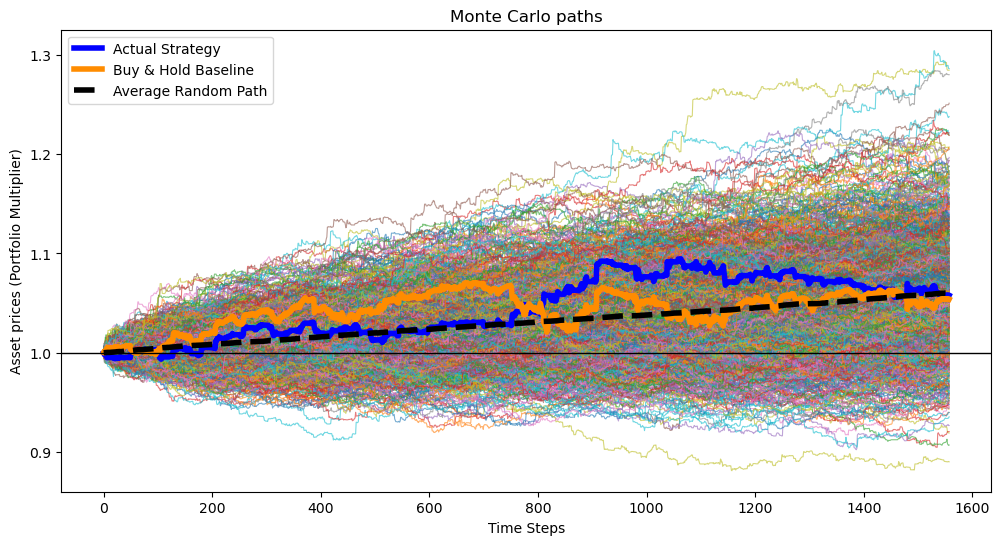

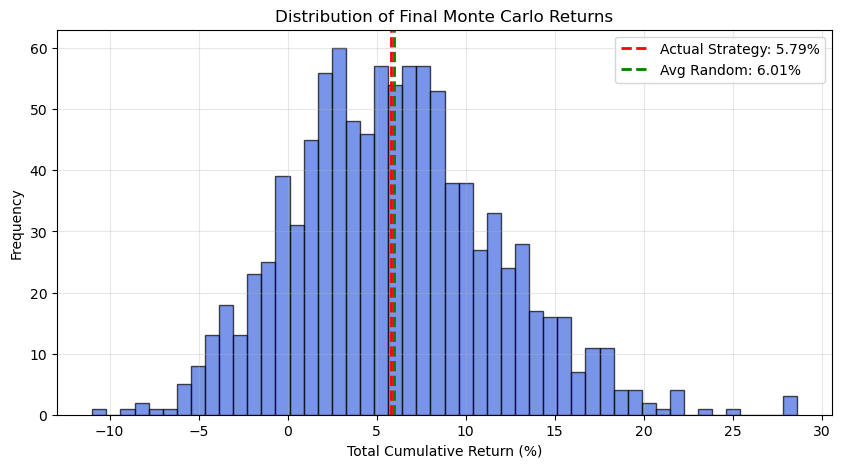

--- MONTE CARLO STATISTICS ---
Actual Strategy Return:   5.79%
Average Random Return:    6.01%
P-Value (Prob. of luck):  0.4990


In [35]:
#Build the best engine we have
ma_length = 100
stop_loss_pct = 0.005
tc_pct = 0.0001

data['SMA_100'] = data['close'].rolling(window=ma_length).mean()
no_lunch_mask = (data.index.time < datetime.time(11, 30)) | (data.index.time >= datetime.time(14, 0))
raw_signal = np.where(data['close'] > data['SMA_100'], 1, -1)
final_signal = np.where(no_lunch_mask, raw_signal, 0)
sig_series = pd.Series(final_signal, index=data.index)
shifted_sig = sig_series.shift(1)
trades_triggered = (sig_series != shifted_sig).astype(int)
raw_ret = shifted_sig * data['market_return']
sl_ret = np.clip(raw_ret, -stop_loss_pct, np.inf)
strategy_returns = sl_ret - (trades_triggered * tc_pct)
strategy_returns = strategy_returns.dropna()
aligned_market_returns = data.loc[strategy_returns.index, 'market_return']
baseline_path = (1 + aligned_market_returns).cumprod().values
num_simulations = 1000
simulated_paths = np.zeros((len(strategy_returns), num_simulations))

print(f"Running {num_simulations} Monte Carlo simulations. Please wait...\n")

#Simulate
for i in range(num_simulations):
    random_returns = np.random.choice(strategy_returns, size=len(strategy_returns), replace=True)
    simulated_paths[:, i] = (1 + random_returns).cumprod()
actual_path = (1 + strategy_returns).cumprod().values

#Visualise
average_path = np.mean(simulated_paths, axis=1)

plt.figure(figsize=(12, 6))

# Removing the color argument creates the multi-colored spaghetti look from your reference image
plt.plot(simulated_paths, alpha=0.6, linewidth=0.8)

plt.plot(actual_path, color='blue', linewidth=4, label='Actual Strategy')
plt.plot(baseline_path, color='darkorange', linewidth=4, label='Buy & Hold Baseline')
plt.plot(average_path, color='black', linewidth=4, linestyle='--', label='Average Random Path')

plt.axhline(1.0, color='black', linewidth=1)
plt.title('Monte Carlo paths')
plt.xlabel('Time Steps')
plt.ylabel('Asset prices (Portfolio Multiplier)')
plt.legend(loc='upper left')

plt.grid(False) 
plt.show()

final_sim_returns = (simulated_paths[-1, :] - 1) * 100
actual_final_return = (actual_path[-1] - 1) * 100

#Calculate the P-Value
paths_beating_actual = np.sum(final_sim_returns >= actual_final_return)
p_value = paths_beating_actual / num_simulations

plt.figure(figsize=(10, 5))
plt.hist(final_sim_returns, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
plt.axvline(actual_final_return, color='red', linestyle='dashed', linewidth=2, label=f'Actual Strategy: {actual_final_return:.2f}%')
plt.axvline(np.mean(final_sim_returns), color='green', linestyle='dashed', linewidth=2, label=f'Avg Random: {np.mean(final_sim_returns):.2f}%')
plt.title('Distribution of Final Monte Carlo Returns')
plt.xlabel('Total Cumulative Return (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Final stats
print("--- MONTE CARLO STATISTICS ---")
print(f"Actual Strategy Return:   {actual_final_return:.2f}%")
print(f"Average Random Return:    {np.mean(final_sim_returns):.2f}%")
print(f"P-Value (Prob. of luck):  {p_value:.4f}")